# Validacao de dados sinteticos

In [3]:
%pip install -q umap-learn


Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    import umap
except ImportError as exc:
    raise ImportError(
        "Instale 'umap-learn' antes de executar o notebook. Rode a celula de setup acima."
    ) from exc

def ensure_project_root_on_sys_path():
    """Encontra e adiciona a raiz do projeto ao sys.path."""
    cwd = Path.cwd().resolve()
    candidate_roots = [cwd, *cwd.parents]
    seen = set()
    for candidate in candidate_roots:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "pose_module").exists():
            if str(candidate) not in sys.path:
                sys.path.insert(0, str(candidate))
            return
    raise RuntimeError("Abra o notebook dentro do repo IMUGPT.")


ensure_project_root_on_sys_path()

from pose_module.robot_emotions.metadata import get_sensor_name

plt.style.use("seaborn-v0_8-whitegrid")

CHANNEL_GROUP_TO_SLICE = {
    "acc": slice(0, 3),
    "gyro": slice(3, 6),
    "both": slice(0, 6),
}
DOMAIN_TO_MARKER = {
    "real": "o",
    "synthetic": "^",
}
DOMAIN_TO_COLOR = {
    "real": "#1f77b4",
    "synthetic": "#ff7f0e",
}

def find_project_root():
    """Encontra a raiz do projeto IMUGPT procurando por pose_module e output."""
    cwd = Path.cwd().resolve()
    candidate_roots = [cwd, *cwd.parents]
    seen = set()
    for candidate in candidate_roots:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "pose_module").exists() and (candidate / "output").exists():
            return candidate
    raise RuntimeError("Abra o notebook dentro do repo IMUGPT.")


def build_capture_table(output_root, filters=None):
    rows = []
    filters = filters or {}
    domains = None if filters.get("domains") is None else {str(value) for value in filters["domains"]}
    actions = None if filters.get("actions") is None else {str(value) for value in filters["actions"]}
    emotions = None if filters.get("emotions") is None else {str(value) for value in filters["emotions"]}
    clip_ids = None if filters.get("clip_ids") is None else {str(value) for value in filters["clip_ids"]}

    for metadata_path in sorted(output_root.rglob("metadata.json")):
        clip_dir = metadata_path.parent
        pose_dir = clip_dir / "pose"
        real_npz_path = clip_dir / "imu.npz"
        virtual_npz_path = pose_dir / "virtual_imu.npz"
        if not real_npz_path.exists() or not virtual_npz_path.exists():
            continue

        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        labels = metadata.get("labels", {})
        row = {
            "clip_id": str(metadata["clip_id"]),
            "domain": str(metadata["domain"]),
            "user_id": int(metadata["user_id"]),
            "tag_number": int(metadata["tag_number"]),
            "take_id": metadata.get("take_id"),
            "emotion": labels.get("emotion"),
            "action": labels.get("action"),
            "stimulus": labels.get("stimulus"),
            "clip_dir": str(clip_dir.resolve()),
            "pose_dir": str(pose_dir.resolve()),
        }
        if domains is not None and row["domain"] not in domains:
            continue
        if actions is not None and str(row["action"]) not in actions:
            continue
        if emotions is not None and str(row["emotion"]) not in emotions:
            continue
        if clip_ids is not None and row["clip_id"] not in clip_ids:
            continue
        rows.append(row)

    frame = pd.DataFrame(rows)
    if frame.empty:
        raise RuntimeError(f"Nenhuma captura encontrada em {output_root} para os filtros escolhidos.")

    return frame.sort_values(
        ["domain", "user_id", "tag_number", "take_id", "clip_id"],
        kind="stable",
    ).reset_index(drop=True)


def resolve_real_sensor_names(metadata, payload, sensor_count):
    if "sensor_ids" in payload:
        sensor_ids = [int(value) for value in np.asarray(payload["sensor_ids"]).tolist()]
        if len(sensor_ids) == int(sensor_count):
            return [get_sensor_name(sensor_id) for sensor_id in sensor_ids]

    metadata_sensor_ids = metadata.get("imu", {}).get("sensor_ids", [])
    if len(metadata_sensor_ids) == int(sensor_count):
        return [get_sensor_name(int(sensor_id)) for sensor_id in metadata_sensor_ids]

    metadata_sensor_names = metadata.get("imu", {}).get("sensor_names", [])
    if len(metadata_sensor_names) == int(sensor_count):
        return [str(value) for value in metadata_sensor_names]

    return [f"sensor_{sensor_index}" for sensor_index in range(int(sensor_count))]


def load_real_capture(clip_dir):
    clip_dir = Path(clip_dir)
    metadata = json.loads((clip_dir / "metadata.json").read_text(encoding="utf-8"))
    with np.load(clip_dir / "imu.npz", allow_pickle=True) as payload:
        values = np.asarray(payload["imu"], dtype=np.float32)
        return {
            "timestamps_sec": np.asarray(payload["timestamps_sec"], dtype=np.float32),
            "values": values,
            "sensor_names": resolve_real_sensor_names(metadata, payload, sensor_count=values.shape[1]),
            "clip_id": str(metadata["clip_id"]),
        }


def load_virtual_capture(pose_dir):
    pose_dir = Path(pose_dir)
    with np.load(pose_dir / "virtual_imu.npz", allow_pickle=True) as payload:
        acc = np.asarray(payload["acc"], dtype=np.float32)
        gyro = np.asarray(payload["gyro"], dtype=np.float32)
        values = np.concatenate([acc, gyro], axis=-1)
        return {
            "timestamps_sec": np.asarray(payload["timestamps_sec"], dtype=np.float32),
            "values": values,
            "sensor_names": [str(value) for value in np.asarray(payload["sensor_names"]).tolist()],
            "clip_id": str(np.asarray(payload["clip_id"]).item()),
        }


In [5]:
def select_sensor_names(requested_sensor_names, real_sensor_names, virtual_sensor_names):
    if requested_sensor_names is None:
        selected_sensor_names = [
            sensor_name
            for sensor_name in virtual_sensor_names
            if sensor_name in real_sensor_names
        ]
    else:
        selected_sensor_names = [str(sensor_name) for sensor_name in requested_sensor_names]

    missing = [
        sensor_name
        for sensor_name in selected_sensor_names
        if sensor_name not in real_sensor_names or sensor_name not in virtual_sensor_names
    ]
    if missing:
        raise ValueError(f"Sensores ausentes no par real/sintetico: {missing}")
    return selected_sensor_names


def reorder_sensors(values, sensor_names, selected_sensor_names):
    indices = [sensor_names.index(sensor_name) for sensor_name in selected_sensor_names]
    return np.asarray(values[:, indices, :], dtype=np.float32)


def resample_window(timestamps_sec, values, num_steps):
    timestamps_sec = np.asarray(timestamps_sec, dtype=np.float64)
    values = np.asarray(values, dtype=np.float32)
    if timestamps_sec.size < 2:
        return None

    duration_sec = float(timestamps_sec[-1] - timestamps_sec[0])
    if duration_sec <= 0.0:
        return None

    source_x = (timestamps_sec - timestamps_sec[0]) / duration_sec
    source_x, unique_indices = np.unique(source_x, return_index=True)
    values = values[unique_indices]
    if source_x.size < 2:
        return None

    target_x = np.linspace(0.0, 1.0, int(num_steps), dtype=np.float64)
    resampled = np.empty((int(num_steps), values.shape[1], values.shape[2]), dtype=np.float32)
    for sensor_index in range(values.shape[1]):
        for channel_index in range(values.shape[2]):
            resampled[:, sensor_index, channel_index] = np.interp(
                target_x,
                source_x,
                values[:, sensor_index, channel_index],
            )
    return resampled


def interpolate_time_series(timestamps_sec, values, target_timestamps_sec):
    timestamps_sec = np.asarray(timestamps_sec, dtype=np.float64)
    values = np.asarray(values, dtype=np.float32)
    target_timestamps_sec = np.asarray(target_timestamps_sec, dtype=np.float64)
    if timestamps_sec.shape[0] != values.shape[0]:
        raise ValueError("timestamps_sec e values precisam ter o mesmo tamanho no eixo temporal.")
    if timestamps_sec.size < 2 or target_timestamps_sec.size == 0:
        return None

    source_timestamps_sec, unique_indices = np.unique(timestamps_sec, return_index=True)
    values = values[unique_indices]
    if source_timestamps_sec.size < 2:
        return None

    interpolated = np.empty(
        (target_timestamps_sec.size, values.shape[1], values.shape[2]),
        dtype=np.float32,
    )
    for sensor_index in range(values.shape[1]):
        for channel_index in range(values.shape[2]):
            interpolated[:, sensor_index, channel_index] = np.interp(
                target_timestamps_sec,
                source_timestamps_sec,
                values[:, sensor_index, channel_index],
            )
    return interpolated


def make_resampled_windows(
    timestamps_sec,
    values,
    window_duration_sec,
    stride_sec,
    num_steps,
    min_coverage=0.80,
):
    timestamps_sec = np.asarray(timestamps_sec, dtype=np.float64)
    values = np.asarray(values, dtype=np.float32)
    if timestamps_sec.shape[0] != values.shape[0]:
        raise ValueError("timestamps_sec e values precisam ter o mesmo tamanho no eixo temporal.")
    if timestamps_sec.size < 2:
        return []

    window_duration_sec = float(window_duration_sec)
    stride_sec = float(stride_sec)
    start_min = float(timestamps_sec[0])
    start_max = float(timestamps_sec[-1] - window_duration_sec)
    if start_max < start_min:
        return []

    starts = np.arange(start_min, start_max + 1e-6, stride_sec, dtype=np.float64)
    windows = []
    for start_sec in starts:
        end_sec = start_sec + window_duration_sec
        mask = (timestamps_sec >= start_sec) & (timestamps_sec < end_sec)
        if int(mask.sum()) < 4:
            continue

        window_t = timestamps_sec[mask]
        window_v = values[mask]
        coverage_sec = float(window_t[-1] - window_t[0])
        if coverage_sec < window_duration_sec * float(min_coverage):
            continue

        resampled = resample_window(window_t, window_v, num_steps=num_steps)
        if resampled is None:
            continue

        windows.append(
            {
                "feature": resampled.reshape(-1).astype(np.float32),
                "start_sec": float(start_sec),
                "end_sec": float(end_sec),
                "num_raw_steps": int(window_v.shape[0]),
            }
        )
    return windows


def make_resampled_points(timestamps_sec, values, stride_sec):
    timestamps_sec = np.asarray(timestamps_sec, dtype=np.float64)
    values = np.asarray(values, dtype=np.float32)
    if timestamps_sec.shape[0] != values.shape[0]:
        raise ValueError("timestamps_sec e values precisam ter o mesmo tamanho no eixo temporal.")
    if timestamps_sec.size < 2:
        return []

    stride_sec = float(stride_sec)
    start_sec = float(timestamps_sec[0])
    end_sec = float(timestamps_sec[-1])
    if end_sec <= start_sec:
        return []

    target_timestamps_sec = np.arange(start_sec, end_sec + 1e-6, stride_sec, dtype=np.float64)
    interpolated = interpolate_time_series(
        timestamps_sec,
        values,
        target_timestamps_sec,
    )
    if interpolated is None:
        return []

    points = []
    for point_index, time_sec in enumerate(target_timestamps_sec):
        points.append(
            {
                "feature": interpolated[point_index].reshape(-1).astype(np.float32),
                "point_index": int(point_index),
                "point_time_sec": float(time_sec),
            }
        )
    return points


def build_window_feature_table(
    captures_df,
    signal_group,
    sensor_names,
    window_duration_sec,
    stride_sec,
    num_resampled_steps,
    min_window_coverage,
):
    if signal_group not in CHANNEL_GROUP_TO_SLICE:
        raise ValueError("signal_group deve ser 'acc', 'gyro' ou 'both'.")

    channel_slice = CHANNEL_GROUP_TO_SLICE[signal_group]
    feature_rows = []
    metadata_rows = []

    for capture in captures_df.itertuples(index=False):
        real_capture = load_real_capture(capture.clip_dir)
        virtual_capture = load_virtual_capture(capture.pose_dir)
        selected_sensor_names = select_sensor_names(
            sensor_names,
            real_capture["sensor_names"],
            virtual_capture["sensor_names"],
        )

        source_payloads = {
            "real": real_capture,
            "synthetic": virtual_capture,
        }
        for source_domain, payload in source_payloads.items():
            values = reorder_sensors(
                payload["values"][:, :, channel_slice],
                payload["sensor_names"],
                selected_sensor_names,
            )
            windows = make_resampled_windows(
                payload["timestamps_sec"],
                values,
                window_duration_sec=window_duration_sec,
                stride_sec=stride_sec,
                num_steps=num_resampled_steps,
                min_coverage=min_window_coverage,
            )

            for window_index, window in enumerate(windows):
                feature_rows.append(window["feature"])
                metadata_rows.append(
                    {
                        "clip_id": capture.clip_id,
                        "domain": capture.domain,
                        "user_id": int(capture.user_id),
                        "tag_number": int(capture.tag_number),
                        "take_id": capture.take_id,
                        "emotion": capture.emotion,
                        "action": capture.action,
                        "stimulus": capture.stimulus,
                        "source_domain": source_domain,
                        "sample_level": "window",
                        "window_index": int(window_index),
                        "window_start_sec": float(window["start_sec"]),
                        "window_end_sec": float(window["end_sec"]),
                        "num_raw_steps": int(window["num_raw_steps"]),
                    }
                )

    if not feature_rows:
        raise RuntimeError("Nenhuma janela valida foi gerada. Revise os filtros e os parametros.")

    feature_matrix = np.vstack(feature_rows).astype(np.float32)
    metadata_df = pd.DataFrame(metadata_rows)
    return feature_matrix, metadata_df


def build_point_feature_table(
    captures_df,
    signal_group,
    sensor_names,
    point_stride_sec,
):
    if signal_group not in CHANNEL_GROUP_TO_SLICE:
        raise ValueError("signal_group deve ser 'acc', 'gyro' ou 'both'.")

    channel_slice = CHANNEL_GROUP_TO_SLICE[signal_group]
    feature_rows = []
    metadata_rows = []

    for capture in captures_df.itertuples(index=False):
        real_capture = load_real_capture(capture.clip_dir)
        virtual_capture = load_virtual_capture(capture.pose_dir)
        selected_sensor_names = select_sensor_names(
            sensor_names,
            real_capture["sensor_names"],
            virtual_capture["sensor_names"],
        )

        source_payloads = {
            "real": real_capture,
            "synthetic": virtual_capture,
        }
        for source_domain, payload in source_payloads.items():
            values = reorder_sensors(
                payload["values"][:, :, channel_slice],
                payload["sensor_names"],
                selected_sensor_names,
            )
            points = make_resampled_points(
                payload["timestamps_sec"],
                values,
                stride_sec=point_stride_sec,
            )

            for point in points:
                feature_rows.append(point["feature"])
                metadata_rows.append(
                    {
                        "clip_id": capture.clip_id,
                        "domain": capture.domain,
                        "user_id": int(capture.user_id),
                        "tag_number": int(capture.tag_number),
                        "take_id": capture.take_id,
                        "emotion": capture.emotion,
                        "action": capture.action,
                        "stimulus": capture.stimulus,
                        "source_domain": source_domain,
                        "sample_level": "point",
                        "point_index": int(point["point_index"]),
                        "point_time_sec": float(point["point_time_sec"]),
                    }
                )

    if not feature_rows:
        raise RuntimeError("Nenhum ponto valido foi gerado. Revise os filtros e os parametros.")

    feature_matrix = np.vstack(feature_rows).astype(np.float32)
    metadata_df = pd.DataFrame(metadata_rows)
    return feature_matrix, metadata_df


def balance_domains(feature_matrix, metadata_df, max_samples_per_domain=None, random_seed=7):
    if max_samples_per_domain is None:
        return feature_matrix, metadata_df.reset_index(drop=True)

    rng = np.random.default_rng(int(random_seed))
    selected_indices = []
    for _, domain_indices in metadata_df.groupby("source_domain").indices.items():
        domain_indices = np.asarray(domain_indices, dtype=np.int64)
        if domain_indices.size > int(max_samples_per_domain):
            domain_indices = rng.choice(domain_indices, size=int(max_samples_per_domain), replace=False)
        selected_indices.extend(domain_indices.tolist())

    selected_indices = np.asarray(sorted(selected_indices), dtype=np.int64)
    return (
        feature_matrix[selected_indices],
        metadata_df.iloc[selected_indices].reset_index(drop=True),
    )


def zscore_features(feature_matrix):
    feature_matrix = np.asarray(feature_matrix, dtype=np.float32)
    mean = feature_matrix.mean(axis=0, keepdims=True)
    std = feature_matrix.std(axis=0, keepdims=True)
    std[std < 1e-6] = 1.0
    return (feature_matrix - mean) / std


def fit_umap(feature_matrix, umap_config):
    reducer = umap.UMAP(**dict(umap_config))
    embedding = reducer.fit_transform(feature_matrix)
    return embedding, reducer


def prepare_categorical_labels(series, top_n=8, other_name="Outros"):
    labels = series.fillna("missing").astype(str)
    if top_n is None or labels.nunique() <= int(top_n):
        return labels
    top_labels = labels.value_counts().head(int(top_n)).index
    return labels.where(labels.isin(top_labels), other_name)


def plot_embedding_by_domain(ax, embedding, metadata_df):
    for domain_name in ["real", "synthetic"]:
        mask = metadata_df["source_domain"].eq(domain_name).to_numpy()
        if not mask.any():
            continue
        ax.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            s=18,
            alpha=0.70,
            label=f"{domain_name} ({int(mask.sum())})",
            c=DOMAIN_TO_COLOR[domain_name],
            marker=DOMAIN_TO_MARKER[domain_name],
            linewidths=0.0,
        )
    ax.set_title("UMAP por dominio")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(loc="best")


def plot_embedding_by_label(ax, embedding, metadata_df, label_column="action", top_n=8):
    labels = prepare_categorical_labels(metadata_df[label_column], top_n=top_n)
    unique_labels = labels.value_counts().index.tolist()
    palette = plt.get_cmap("tab10")(np.linspace(0.0, 1.0, max(len(unique_labels), 2)))
    color_map = {
        label_name: palette[index % len(palette)]
        for index, label_name in enumerate(unique_labels)
    }

    for label_name in unique_labels:
        for domain_name in ["real", "synthetic"]:
            mask = (
                labels.eq(label_name)
                & metadata_df["source_domain"].eq(domain_name)
            ).to_numpy()
            if not mask.any():
                continue
            ax.scatter(
                embedding[mask, 0],
                embedding[mask, 1],
                s=18,
                alpha=0.65,
                label=f"{label_name} | {domain_name}",
                c=[color_map[label_name]],
                marker=DOMAIN_TO_MARKER[domain_name],
                linewidths=0.0,
            )

    ax.set_title(f"UMAP por {label_column} (cor) e dominio (marcador)")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, ncol=1)


In [6]:
def process():
    if EMBED_LEVEL == "window":
        feature_matrix, metadata_df = build_window_feature_table(
            captures_df,
            signal_group=SIGNAL_GROUP,
            sensor_names=SENSOR_NAMES,
            window_duration_sec=WINDOW_DURATION_SEC,
            stride_sec=WINDOW_STRIDE_SEC,
            num_resampled_steps=NUM_RESAMPLED_STEPS,
            min_window_coverage=MIN_WINDOW_COVERAGE,
        )
        level_summary = {
            "window_duration_sec": WINDOW_DURATION_SEC,
            "stride_sec": WINDOW_STRIDE_SEC,
            "resampled_steps": NUM_RESAMPLED_STEPS,
        }
    elif EMBED_LEVEL == "point":
        feature_matrix, metadata_df = build_point_feature_table(
            captures_df,
            signal_group=SIGNAL_GROUP,
            sensor_names=SENSOR_NAMES,
            point_stride_sec=POINT_STRIDE_SEC,
        )
        level_summary = {
            "point_stride_sec": POINT_STRIDE_SEC,
        }
    else:
        raise ValueError("EMBED_LEVEL deve ser 'window' ou 'point'.")

    feature_matrix, metadata_df = balance_domains(
        feature_matrix,
        metadata_df,
        max_samples_per_domain=MAX_SAMPLES_PER_DOMAIN,
        random_seed=RANDOM_SEED,
    )

    summary_row = {
        "embedding_level": EMBED_LEVEL,
        "num_samples": int(feature_matrix.shape[0]),
        "feature_dim": int(feature_matrix.shape[1]),
        "signal_group": SIGNAL_GROUP,
        "sensor_names": ", ".join(SENSOR_NAMES) if SENSOR_NAMES is not None else "auto",
    }
    summary_row.update(level_summary)
    summary_df = pd.DataFrame([summary_row])
    display(summary_df)

    display(
        metadata_df.groupby("source_domain")
        .size()
        .rename("num_samples")
        .reset_index()
    )

    label_counts = pd.crosstab(
        metadata_df[LABEL_COLUMN].fillna("missing"),
        metadata_df["source_domain"],
    )
    label_counts["total"] = label_counts.sum(axis=1)
    display(label_counts.sort_values("total", ascending=False).head(12))
    
    feature_matrix_z = zscore_features(feature_matrix)
    
    embedding, reducer = fit_umap(feature_matrix_z, UMAP_CONFIG)

    embedding_df = metadata_df.copy()
    embedding_df["umap_1"] = embedding[:, 0]
    embedding_df["umap_2"] = embedding[:, 1]

    display(embedding_df.head())


    if EMBED_LEVEL == "window":
        level_title = f"janela {WINDOW_DURATION_SEC:.1f}s"
    else:
        level_title = f"ponto reamostrado a cada {POINT_STRIDE_SEC:.2f}s"

    fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

    plot_embedding_by_domain(axes[0], embedding, embedding_df)
    plot_embedding_by_label(
        axes[1],
        embedding,
        embedding_df,
        label_column=LABEL_COLUMN,
        top_n=TOP_LABELS_TO_SHOW,
    )

    fig.suptitle(
        f"UMAP real x sintetico | {SIGNAL_GROUP} | {level_title}",
        y=1.03,
        fontsize=14,
    )
    plt.show()


,clip_id,domain,user_id,tag_number,take_id,emotion,action
0,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing
1,robot_emotions_10ms_u02_tag05,10ms,2,5,NaN,Sadness,Sitting + free arm movement
2,robot_emotions_10ms_u02_tag06,10ms,2,6,NaN,Sadness,Free arm movement + sitting
3,robot_emotions_10ms_u02_tag07,10ms,2,7,NaN,Sadness,Free arm movement + standing
4,robot_emotions_10ms_u02_tag09,10ms,2,9,NaN,Happiness,Sitting + free arm movement
5,robot_emotions_10ms_u02_tag10,10ms,2,10,NaN,Happiness,Gesturing with arms raised + sitting
6,robot_emotions_10ms_u02_tag11,10ms,2,11,NaN,Happiness,Gesturing with arms raised + raised
7,robot_emotions_10ms_u02_tag16,10ms,2,16,NaN,Boredom,Sitting + free arm movement
8,robot_emotions_10ms_u02_tag17,10ms,2,17,NaN,Boredom,Standing + free arm movement
9,robot_emotions_10ms_u02_tag18,10ms,2,18,NaN,Curiosity,Free movement of the still body


,domain,num_captures
0,10ms,36
1,30ms,53


,action,num_captures
0,Sitting + free arm movement,25
1,Standing,10
2,Gesturing with arms raised + sitting,9
3,Sitting,9
4,Free arm movement + sitting,8
5,Standing + free arm movement,7
6,Free movement of the still body,7
7,Free arm movement + standing,6
8,Gesturing with arms raised + raised,5
9,Bounce + free arm movement,3


,embedding_level,num_samples,feature_dim,signal_group,sensor_names,point_stride_sec
0,point,1500,12,both,"right_forearm, left_forearm",0.1


,source_domain,num_samples
0,real,750
1,synthetic,750


source_domain,real,synthetic,total
action,,,
Sitting + free arm movement,220,234,454
Gesturing with arms raised + sitting,84,76,160
Sitting,78,81,159
Standing,78,79,157
Free arm movement + sitting,83,69,152
Free movement of the still body,44,54,98
Standing + free arm movement,47,49,96
Gesturing with arms raised + raised,43,44,87
Free arm movement + standing,41,35,76


/home/henriquesouza/IMUGPT/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,clip_id,domain,user_id,tag_number,take_id,emotion,action,stimulus,source_domain,sample_level,point_index,point_time_sec,umap_1,umap_2
0,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,N.A.,real,point,340,34.0,10.679861,7.737494
1,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,N.A.,real,point,394,39.4,10.847701,8.022647
2,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,N.A.,real,point,548,54.8,10.829140,8.290181
3,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,N.A.,real,point,556,55.6,10.702114,8.344009
4,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,N.A.,real,point,802,80.2,10.936817,8.128293


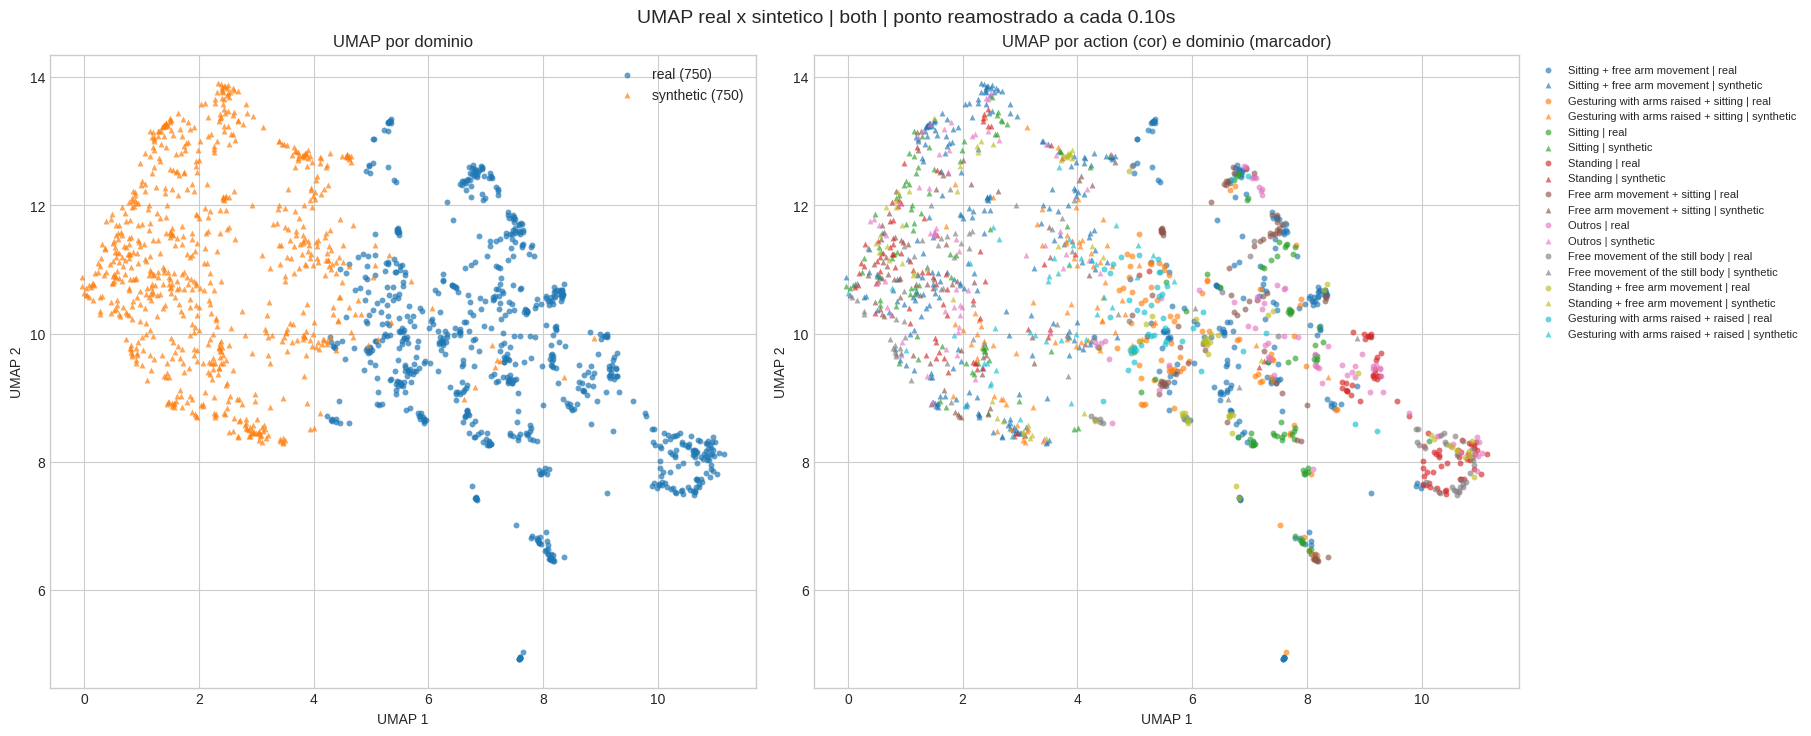

In [7]:

PROJECT_ROOT = find_project_root()
OUTPUT_ROOT = PROJECT_ROOT / "output" / "robot_emotions_virtual_imu_final_v1"

FILTERS = {
    "domains": None,
    "actions": None,
    "emotions": None,
    "clip_ids": None,
}

EMBED_LEVEL = "point"  # "window" ou "point"
SIGNAL_GROUP = "both"  # "acc", "gyro" ou "both"
SENSOR_NAMES = ["right_forearm", "left_forearm"]  # None para usar a intersecao comum
WINDOW_DURATION_SEC = 4.0
WINDOW_STRIDE_SEC = 2.0
NUM_RESAMPLED_STEPS = 96
MIN_WINDOW_COVERAGE = 0.80
POINT_STRIDE_SEC = 0.10
MAX_SAMPLES_PER_DOMAIN = 750
RANDOM_SEED = 7

LABEL_COLUMN = "action"
TOP_LABELS_TO_SHOW = 8

UMAP_CONFIG = {
    "n_neighbors": 30,
    "min_dist": 0.10,
    "metric": "euclidean",
    "random_state": RANDOM_SEED,
}

captures_df = build_capture_table(OUTPUT_ROOT, filters=FILTERS)

display(
    captures_df[
        ["clip_id", "domain", "user_id", "tag_number", "take_id", "emotion", "action"]
    ].head(10)
)

display(
    captures_df.groupby("domain")
    .size()
    .rename("num_captures")
    .reset_index()
)

display(
    captures_df["action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="num_captures")
    .head(12)
)

process()